# Penrose Ammann Lines via A₄ Coxeter Theory

This notebook derives every parameter of the Penrose Ammann-line construction
algebraically from the A₄ root system, using the same SageMath approach as
`hexadic_diamond_coxeter.ipynb`, then reproduces the numerical Ammann-line
computation of `penrose_coxeter.ipynb`.

**References**
- Boyle & Steinhardt, *Coxeter Pairs, Ammann Patterns, and Penrose-like Tilings*, arXiv:1608.08215v4 
- Boyle & Steinhardt, *Self-Similar One-Dimensional Quasilattices*,
  arXiv:1608.08215 / arXiv:1608.08220

In [1]:
import sys
sys.path.insert(0, '../src')
from coxeter_a4 import build_a4_system, build_eigenspaces, eigenvec_to_proj, algebraic_constants

from sage.all import n as numerical
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

## 1. A₄ root system and Coxeter element

The Coxeter element of W(A₄) = S₅ is the product of all simple reflections
taken in order: cox = s₁·s₂·s₃·s₄. Its matrix representation in the ε-basis
is the 5×5 cyclic permutation P: εᵢ → εᵢ₊₁ (mod 5). This is the same matrix
used in the Penrose cut-and-project construction.

In [2]:
R, ambient, W, s, cox, P = build_a4_system()
print('Coxeter element matrix P (cyclic permutation εᵢ → εᵢ₊₁):')
print(P)

Coxeter element matrix P (cyclic permutation εᵢ → εᵢ₊₁):
[0 0 0 0 1]
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]


In [3]:
W_keys = W.reflections().keys()
for key in W_keys:
    print(key)
    print(W.reflections()[key])

(1, -1, 0, 0, 0)
[0 1 0 0 0]
[1 0 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]
[0 0 0 0 1]
(0, 1, -1, 0, 0)
[1 0 0 0 0]
[0 0 1 0 0]
[0 1 0 0 0]
[0 0 0 1 0]
[0 0 0 0 1]
(0, 0, 1, -1, 0)
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 0 1 0]
[0 0 1 0 0]
[0 0 0 0 1]
(0, 0, 0, 1, -1)
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 0 1]
[0 0 0 1 0]
(1, 0, -1, 0, 0)
[0 0 1 0 0]
[0 1 0 0 0]
[1 0 0 0 0]
[0 0 0 1 0]
[0 0 0 0 1]
(0, 1, 0, -1, 0)
[1 0 0 0 0]
[0 0 0 1 0]
[0 0 1 0 0]
[0 1 0 0 0]
[0 0 0 0 1]
(0, 0, 1, 0, -1)
[1 0 0 0 0]
[0 1 0 0 0]
[0 0 0 0 1]
[0 0 0 1 0]
[0 0 1 0 0]
(1, 0, 0, -1, 0)
[0 0 0 1 0]
[0 1 0 0 0]
[0 0 1 0 0]
[1 0 0 0 0]
[0 0 0 0 1]
(0, 1, 0, 0, -1)
[1 0 0 0 0]
[0 0 0 0 1]
[0 0 1 0 0]
[0 0 0 1 0]
[0 1 0 0 0]
(1, 0, 0, 0, -1)
[0 0 0 0 1]
[0 1 0 0 0]
[0 0 1 0 0]
[0 0 0 1 0]
[1 0 0 0 0]


## 2. Eigenspaces over Q(ζ₅): parallel and perpendicular planes

P has eigenvalues ωᵏ = e^(2πik/5) for k = 0,1,2,3,4. The two real 2-planes of
interest are:

- **E∥** (k = 1,4, eigenvalue ζ₅ and ζ₅⁴): rotation by 72° — physical space
  of the Penrose tiling
- **E⊥** (k = 2,3, eigenvalue ζ₅² and ζ₅³): rotation by 144° — phason space

In [4]:
K, zeta, w_par, w_perp = build_eigenspaces(P)
print('E∥ eigenvector (over Q(ζ₅)):', w_par)
print('E⊥ eigenvector (over Q(ζ₅)):', w_perp)

E∥ eigenvector (over Q(ζ₅)): (1, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^3, zeta5^2, zeta5)
E⊥ eigenvector (over Q(ζ₅)): (1, zeta5^3, zeta5, -zeta5^3 - zeta5^2 - zeta5 - 1, zeta5^2)


## 3. Projection matrices for E∥ and E⊥

Each complex eigenvector w splits into real and imaginary parts via the complex
embedding K → ℂ. These two real 5-vectors span the corresponding eigenplane and,
after normalization, form a 2×5 orthonormal projection matrix.

In [5]:
proj_par  = eigenvec_to_proj(w_par,  K)   # 2×5, E∥
proj_perp = eigenvec_to_proj(w_perp, K)   # 2×5, E⊥

print('E∥ projection matrix (2×5):')
print(proj_par)
print('E⊥ projection matrix (2×5):')
print(proj_perp)

# Verify rotation angles between consecutive projected basis vectors
eps = np.eye(5)
e1_par  = proj_par  @ eps[1]; e1_par  /= np.linalg.norm(e1_par)
e2_par  = proj_par  @ eps[2]; e2_par  /= np.linalg.norm(e2_par)
e1_perp = proj_perp @ eps[1]; e1_perp /= np.linalg.norm(e1_perp)
e2_perp = proj_perp @ eps[2]; e2_perp /= np.linalg.norm(e2_perp)
angle_par  = np.degrees(np.arccos(np.clip(np.dot(e1_par,  e2_par),  -1, 1)))
angle_perp = np.degrees(np.arccos(np.clip(np.dot(e1_perp, e2_perp), -1, 1)))
print(f'Angle between consecutive E∥  basis vectors: {angle_par:.4f}° (expect 72°)')
print(f'Angle between consecutive E⊥ basis vectors: {angle_perp:.4f}° (expect 144°)')

E∥ projection matrix (2×5):
[[ 0.63245553  0.19543951 -0.51166727 -0.51166727  0.19543951]
 [-0.          0.60150096  0.37174803 -0.37174803 -0.60150096]]
E⊥ projection matrix (2×5):
[[ 0.63245553 -0.51166727  0.19543951  0.19543951 -0.51166727]
 [-0.          0.37174803 -0.60150096  0.60150096 -0.37174803]]
Angle between consecutive E∥  basis vectors: 72.0000° (expect 72°)
Angle between consecutive E⊥ basis vectors: 144.0000° (expect 144°)


## 4. Star vectors as projections of A₄ basis vectors

The five star vectors a_j⁺ = (cos 2πj/5, sin 2πj/5) of the Penrose Ammann
pattern are simply the projections of the A₄ basis vectors εⱼ onto E∥,
unit-normalised. Their perpendicular projections onto E⊥ give the Galois
conjugate star a_j⁻ = (cos 4πj/5, sin 4πj/5).

In [6]:
proj_eps = [proj_par @ eps[j] for j in range(5)]
scale = np.linalg.norm(proj_eps[0])          # should be √(2/5)
print(f'Scale factor ||proj_par(ε₀)|| = {scale:.6f}  (expect √(2/5) = {np.sqrt(2/5):.6f})')

a_p = np.array([v / np.linalg.norm(v) for v in proj_eps])             # 5×2, E∥ star
a_m = np.array([proj_perp @ eps[j] / np.linalg.norm(proj_perp @ eps[j])
                for j in range(5)])                                    # 5×2, E⊥ star

print('\na_p (E∥ star vectors, should be cos/sin 2πj/5):')
for j, v in enumerate(a_p):
    expected = np.array([np.cos(2*np.pi*j/5), np.sin(2*np.pi*j/5)])
    print(f'  j={j}: {v}  match={np.allclose(v, expected)}')

Scale factor ||proj_par(ε₀)|| = 0.632456  (expect √(2/5) = 0.632456)

a_p (E∥ star vectors, should be cos/sin 2πj/5):
  j=0: [1. 0.]  match=True
  j=1: [0.30901699 0.95105652]  match=True
  j=2: [-0.80901699  0.58778525]  match=True
  j=3: [-0.80901699 -0.58778525]  match=True
  j=4: [ 0.30901699 -0.95105652]  match=True


## 5. Tiling parameters m₁±, m₂±, κ₁ from cyclotomic arithmetic

The ratio of projected squared norms of d=2 vs d=1 A₄ roots equals τ² exactly
in Q(ζ₅). This fixes the golden ratio, and from it all Ammann-line parameters
follow. Specifically:

- √5 = ζ + ζ⁴ − ζ² − ζ³  (real element of Q(ζ₅))
- m₁⁺ = (5 − √5)/10,  m₂⁺ = 1/√5  →  m₂⁺/m₁⁺ = τ
- m₁⁻, m₂⁻ are their Galois conjugates under √5 → −√5
- κ₁ = 1/τ  (density of long tiles in each Fibonacci quasilattice)

In [7]:
consts = algebraic_constants(K, zeta)

# Unpack exact Q(ζ₅) values
sqrt5          = consts['sqrt5']
tau_exact      = consts['tau_exact']
sigma_exact    = consts['sigma_exact']
kappa1_exact   = consts['kappa1_exact']
m1_plus_exact  = consts['m1_plus_exact']
m2_plus_exact  = consts['m2_plus_exact']
m1_minus_exact = consts['m1_minus_exact']
m2_minus_exact = consts['m2_minus_exact']

# Unpack float values for downstream numpy computation
TAU      = consts['TAU']
SIGMA    = consts['SIGMA']
KAPPA_1  = consts['KAPPA_1']
M1_PLUS  = consts['M1_PLUS']
M2_PLUS  = consts['M2_PLUS']
M1_MINUS = consts['M1_MINUS']
M2_MINUS = consts['M2_MINUS']

print(f'√5  = {sqrt5} ≈ {float(numerical(sqrt5).real()):.6f}')
print(f'τ   = {tau_exact} ≈ {TAU:.6f}')
print(f'σ   = {sigma_exact} ≈ {SIGMA:.6f}')
print(f'κ₁  = {kappa1_exact} ≈ {KAPPA_1:.6f}')
print(f'm₁⁺ = {m1_plus_exact} ≈ {M1_PLUS:.6f}')
print(f'm₂⁺ = {m2_plus_exact} ≈ {M2_PLUS:.6f}')
print(f'm₂⁺/m₁⁺ = τ? {m2_plus_exact / m1_plus_exact == tau_exact}')
print(f'm₁⁻ = {m1_minus_exact} ≈ {M1_MINUS:.6f}')
print(f'm₂⁻ = {m2_minus_exact} ≈ {M2_MINUS:.6f}')

√5  = -2*zeta5^3 - 2*zeta5^2 - 1 ≈ 2.236068
τ   = -zeta5^3 - zeta5^2 ≈ 1.618034
σ   = zeta5^3 + zeta5^2 + 1 ≈ -0.618034
κ₁  = -zeta5^3 - zeta5^2 - 1 ≈ 0.618034
m₁⁺ = 1/5*zeta5^3 + 1/5*zeta5^2 + 3/5 ≈ 0.276393
m₂⁺ = -2/5*zeta5^3 - 2/5*zeta5^2 - 1/5 ≈ 0.447214
m₂⁺/m₁⁺ = τ? True
m₁⁻ = -1/5*zeta5^3 - 1/5*zeta5^2 + 2/5 ≈ 0.723607
m₂⁻ = 2/5*zeta5^3 + 2/5*zeta5^2 + 1/5 ≈ -0.447214


## 6. Translation vector q₀ and decomposition into E∥ ⊕ E⊥

The offset vector q₀ is expressed as a rational combination of the four
simple roots of A₄ (equivalently, four coefficients of the fundamental roots),
then projected onto E∥ (translational phase) and E⊥ (phason phase).
The coefficients are chosen so that q₀ = (4/5,−1/5,−1/5,−1/5,−1/5),
matching the `shiftVector` used in `penrose5D.ipynb`.
Galois conjugation redistributes the same rational coefficients very differently
between the two subspaces: |q₀⁻| >> |q₀⁺|.

In [8]:
from sage.all import QQ

# Simple roots of A₄ from the ambient space object (1-indexed: α₁…α₄)
# αᵢ = εᵢ − εᵢ₊₁  →  e.g. α₁ = (1,−1,0,0,0)
# The Coxeter paper's fundamental roots fᵢ are the negative simple roots: fᵢ = −αᵢ
# e.g. f₁ = (−1,+1,0,0,0),  f₂ = (0,−1,+1,0,0), …
alpha = ambient.simple_roots()
print('A₄ simple roots (αᵢ = εᵢ − εᵢ₊₁):')
for i in range(1, 5):
    print(f'  α{i} =', alpha[i].to_vector())

# Coefficients matching shiftVector = (4/5,−1/5,−1/5,−1/5,−1/5) from penrose5D.ipynb
# q5_0 = −Σ cᵢ αᵢ, so cᵢ = (−4/5, −3/5, −2/5, −1/5)
q_0_coeffs = {1: QQ(-4)/5, 2: QQ(-3)/5, 3: QQ(-2)/5, 4: QQ(-1)/5}
q5_0_sage = sum(-q_0_coeffs[i] * alpha[i].to_vector() for i in range(1, 5))
print('\nq5_0 (exact, in Q):', q5_0_sage)

q5_0 = np.array([float(c) for c in q5_0_sage])
qp_0 = proj_par  @ q5_0    # parallel part (translational)
qm_0 = proj_perp @ q5_0    # perpendicular part (phason)

print('q5_0 (float):', q5_0)
print('q₀⁺ (E∥, translational):', qp_0, '  |q₀⁺| =', np.linalg.norm(qp_0))
print('q₀⁻ (E⊥, phason):       ', qm_0, '  |q₀⁻| =', np.linalg.norm(qm_0))
print('Ratio |q₀⁻|/|q₀⁺| =', np.linalg.norm(qm_0)/np.linalg.norm(qp_0))

A₄ simple roots (αᵢ = εᵢ − εᵢ₊₁):
  α1 = (1, -1, 0, 0, 0)
  α2 = (0, 1, -1, 0, 0)
  α3 = (0, 0, 1, -1, 0)
  α4 = (0, 0, 0, 1, -1)

q5_0 (exact, in Q): (4/5, -1/5, -1/5, -1/5, -1/5)
q5_0 (float): [ 0.8 -0.2 -0.2 -0.2 -0.2]
q₀⁺ (E∥, translational): [ 6.32455532e-01 -7.19978571e-18]   |q₀⁺| = 0.6324555320336759
q₀⁻ (E⊥, phason):        [ 6.32455532e-01 -2.08527858e-17]   |q₀⁻| = 0.6324555320336759
Ratio |q₀⁻|/|q₀⁺| = 1.0


### 6a. Convert a `penrose5D.ipynb`-style `shiftVector` to `q_0_coeffs`

Inverting `q5_0 = −Σ cᵢ αᵢ` with αᵢ = εᵢ − εᵢ₊₁ gives a closed form:

    cᵢ = −(s₀ + s₁ + … + s_{i−1})   for i = 1..4

provided Σ sⱼ = 0 (i.e. the shift lies in the A₄ root space). Use
`exact=True` when the entries are exact rationals (e.g. `4/5`), and leave
it `False` for the optimized-float shifts from `penrose5D.ipynb` (e.g.
`[-0.498245, 0.514403, …]`, where no exact Q(ζ₅) representation exists).

Running this cell overrides the `q_0_coeffs`, `q5_0_sage`, `q5_0`,
`qp_0`, `qm_0` values set in the previous cell.

In [9]:
from fractions import Fraction

def shift_to_q0_coeffs(shiftVector, tol=1e-6, exact=False):
    """Convert a 5-element shiftVector (as in penrose5D.ipynb) to the
    q_0 coefficients cᵢ such that q5_0 = -Σ cᵢ αᵢ, with αᵢ = εᵢ − εᵢ₊₁.
    Requires Σ sᵢ ≈ 0 (shift lies in the A₄ root space)."""
    s = list(shiftVector)
    assert len(s) == 5, 'shiftVector must have 5 elements'
    total = sum(float(x) for x in s)
    assert abs(total) < tol, f'shiftVector must sum to 0, got {total}'
    if exact:
        s_q = [QQ(Fraction(x).limit_denominator(10**6)) for x in s]
        return {i: -sum(s_q[:i]) for i in range(1, 5)}
    return {i: -sum(s[:i]) for i in range(1, 5)}

# Example A: exact rational shift matching cell 6 hardcoded case
# shiftVector = (QQ(4)/5, QQ(-1)/5, QQ(-1)/5, QQ(-1)/5, QQ(-1)/5)
# q_0_coeffs = shift_to_q0_coeffs(shiftVector, exact=True)

# Example B: optimized float shift from penrose5D.ipynb (uncomment to use)
shiftVector = np.array([-0.498245, 0.514403, -0.5, 0.474354, 0.009487])
q_0_coeffs = shift_to_q0_coeffs(shiftVector, exact=False)

print('q_0_coeffs =', q_0_coeffs)

# Recompute q5_0 and its parallel/perpendicular projections using the
# possibly-new q_0_coeffs. Works for both exact (QQ) and float coeffs.
q5_0_sage = sum(-q_0_coeffs[i] * alpha[i].to_vector() for i in range(1, 5))
q5_0 = np.array([float(c) for c in q5_0_sage])
qp_0 = proj_par  @ q5_0
qm_0 = proj_perp @ q5_0

print('q5_0 (exact/float):', q5_0_sage)
print('q5_0 (float):      ', q5_0)
print('q₀⁺ (E∥):', qp_0, '  |q₀⁺| =', np.linalg.norm(qp_0))
print('q₀⁻ (E⊥):', qm_0, '  |q₀⁻| =', np.linalg.norm(qm_0))

q_0_coeffs = {1: np.float64(0.498245), 2: np.float64(-0.01615800000000006), 3: np.float64(0.48384199999999994), 4: np.float64(0.009487999999999941)}
q5_0 (exact/float): [-0.498245  0.514403 -0.5       0.474354  0.009488]
q5_0 (float):       [-0.498245  0.514403 -0.5       0.474354  0.009488]
q₀⁺ (E∥): [-0.19960659 -0.05850733]   |q₀⁺| = 0.20800456205145934
q₀⁻ (E⊥): [-0.58818793  0.77377602]   |q₀⁻| = 0.9719538919412694


## 7. Phase parameters χ₁± for each Ammann direction

For each of the 5 Ammann families j, the translational phase χ₁ⱼ⁺ and the
phason phase χ₁ⱼ⁻ are computed from q₀⁺ and q₀⁻ via Eq. (18) of the
Coxeter paper. χ⁺ produces only a rigid shift of the multigrid; χ⁻ enters
the floor function and controls the L/S ordering of tiles.

In [10]:
b_p = TAU   * a_p    # b⁺ⱼ = τ · a⁺ⱼ
b_m = SIGMA * a_m    # b⁻ⱼ = σ · a⁻ⱼ
α, β = 0, 0

χ_1p = np.zeros(5)
χ_1m = np.zeros(5)
for i in range(5):
    χ_1p[i] = (np.dot(M1_PLUS*a_p[i]  + M2_PLUS*b_p[i],  qp_0) - (M1_PLUS*α + M2_PLUS*β)) / M1_PLUS
    χ_1m[i] = (np.dot(M1_MINUS*a_m[i] + M2_MINUS*b_m[i], qm_0) - (M1_MINUS*α + M2_MINUS*β)) / M1_MINUS

print('χ₁⁺ (translational phases):', χ_1p)
print('χ₁⁻ (phason phases):       ', χ_1m)

χ₁⁺ (translational phases): [-0.72218342 -0.42448803  0.45983539  0.70868193 -0.02184587]
χ₁⁻ (phason phases):        [-0.81285572  1.28615177 -1.26818155  0.76580909  0.02907642]


## 8. Ammann line positions: 1D quasilattice formula

For each family j and index n ∈ [-10, 10], the signed distance x[j,n] of the
n-th Ammann line from the origin along direction a⁺ⱼ is given by Eq. (14)
of arXiv:1608.08215:

    x[j,n] = m₁⁺(n − χ₁ⱼ⁺) + (m₂⁺ − m₁⁺)(⌊κ₁(n − χ₁ⱼ⁻)⌋ + 0.5)

The floor function makes lines alternate between the long (L = m₂⁺) and short
(S = m₁⁺) spacings in the Fibonacci ratio.

In [11]:
n_range = (-10, 10)
ns = np.arange(n_range[0], n_range[1] + 1)
x = np.zeros((5, len(ns)))
for i in range(5):
    x[i,:] = M1_PLUS*(ns - χ_1p[i]) + (M2_PLUS - M1_PLUS)*(np.floor(KAPPA_1*(ns - χ_1m[i])) + 0.5)

print('x array (5 families × 21 positions):')
print(x)

x array (5 families × 21 positions):
[[-3.5038376  -3.22744439 -2.7802308  -2.3330172  -2.056624   -1.60941041
  -1.16219681 -0.88580361 -0.43859001 -0.16219681  0.28501679  0.73223038
   1.00862358  1.45583718  1.73223038  2.17944398  2.62665757  2.90305077
   3.35026437  3.79747796  4.07387117]
 [-3.75693897 -3.48054577 -3.03333218 -2.75693897 -2.30972538 -1.86251178
  -1.58611858 -1.13890498 -0.86251178 -0.41529819  0.03191541  0.30830861
   0.75552221  1.2027358   1.479129    1.9263426   2.2027358   2.6499494
   3.09716299  3.3735562   3.82076979]
 [-3.83053956 -3.38332597 -3.10693276 -2.65971917 -2.21250557 -1.93611237
  -1.48889878 -1.21250557 -0.76529198 -0.31807838 -0.04168518  0.40552842
   0.85274201  1.12913521  1.57634881  1.85274201  2.29995561  2.7471692
   3.0235624   3.470776    3.7471692 ]
 [-4.07013945 -3.79374624 -3.34653265 -2.89931905 -2.62292585 -2.17571226
  -1.72849866 -1.45210546 -1.00489186 -0.72849866 -0.28128506  0.16592853
   0.44232173  0.88953533  1.16592

## 9. Plot Ammann lines

Each value x[j,n] is the signed distance from the origin along the normal a⁺ⱼ.
The corresponding Ammann line passes through x[j,n]·a⁺ⱼ and runs perpendicular
to a⁺ⱼ. The five families together form the pentagrid underlying the Penrose tiling.

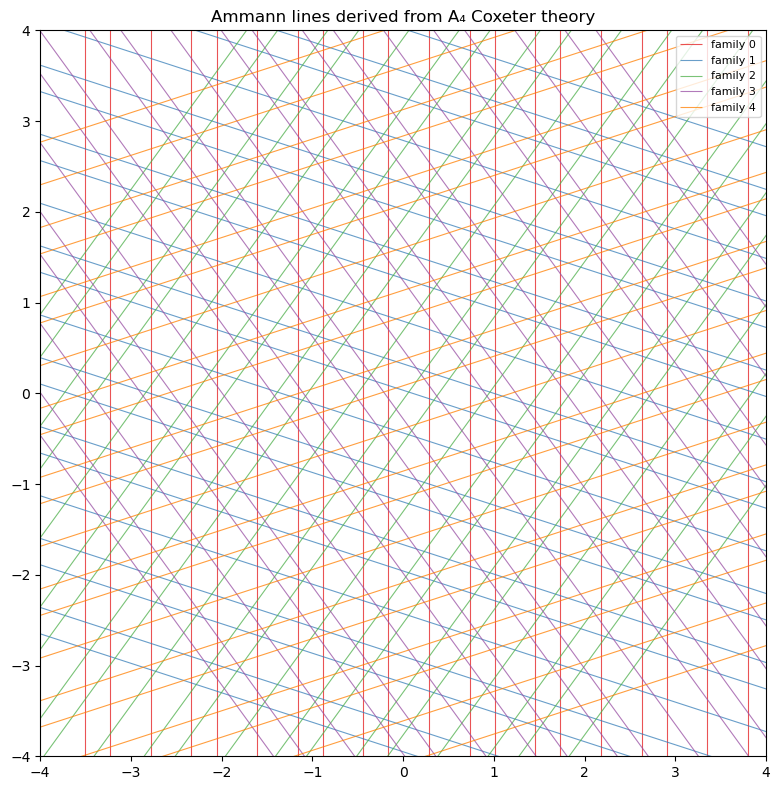

In [12]:
HALF_LEN = 6.0
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, ax = plt.subplots(figsize=(8, 8))
for j in range(5):
    normal  = a_p[j]
    tangent = np.array([-normal[1], normal[0]])
    segs = [[xn*normal - HALF_LEN*tangent, xn*normal + HALF_LEN*tangent]
            for xn in x[j]]
    ax.add_collection(LineCollection(segs, color=COLORS[j], linewidth=0.8,
                                     alpha=0.75, label=f'family {j}'))
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Ammann lines derived from A₄ Coxeter theory')
plt.tight_layout()
plt.show()

## 10. Dualization constant C and rhomb side length

The pentagrid is dualized to the Penrose tiling via Eq. (32) of arXiv:1608.08215:

    x′ = −q₀⁺ + (m̄⁺/γ) Σⱼ Kⱼ eⱼ

where:
- **Kⱼ(r)** = integer cell index of point r in family j (count of Ammann lines
  of family j lying "below" r along direction a_p[j])
- **m̄⁺** = κ₁·m₂⁺ + κ₂·m₁⁺ — average step size of the Fibonacci quasilattice
- **γ = 5/2** — frame constant: Σⱼ eⱼᵅ eⱼᵝ = γ δᵅᵝ (Eq. 25)
- **C = m̄⁺/γ** — dualization scale; equals the side length of every rhomb tile

Each bounded multigrid cell maps to one vertex. The rhomb at the intersection of
families j and k has four vertices whose K-tuples differ only in their j and k
components, so its side vectors are C·a_p[j] and C·a_p[k].

In [13]:
KAPPA_2     = 2.0 - TAU                              # κ₂ = 2 − τ
M_BAR_PLUS  = KAPPA_1 * M2_PLUS + KAPPA_2 * M1_PLUS  # m̄⁺
GAMMA_COEFF = 5.0 / 2.0                              # γ
C_DUAL      = M_BAR_PLUS / GAMMA_COEFF               # Eq. (32) scale = rhomb side length

print(f'κ₂      = {KAPPA_2:.6f}')
print(f'm̄⁺     = {M_BAR_PLUS:.6f}')
print(f'C_DUAL  = {C_DUAL:.6f}  (rhomb side length)')

κ₂      = 0.381966
m̄⁺     = 0.381966
C_DUAL  = 0.152786  (rhomb side length)


## 11. Pentagrid cell indices and rhomb vertices

For each pair of families (j, k) and each pair of Ammann line indices (idx_j, idx_k),
the intersection point r_int is the solution of the 2×2 system:

    [a_p[j]] · r  =  x[j, idx_j]
    [a_p[k]] · r  =  x[k, idx_k]

The integer cell index for family i at point r is:

    Kᵢ(r) = searchsorted(x[i], a_p[i]·r, side='right')

which counts the Ammann lines of family i that lie strictly below r.
The four cells meeting at r_int are obtained by independently decrementing
Kⱼ and Kₖ by 0 or 1. Each cell K = (K₀,…,K₄) dualizes to the vertex

    v(K) = C · Σᵢ Kᵢ · a_p[i] − q₀⁺

and the four vertices form one rhomb tile. The tile is **fat** (72° acute angle)
when the cyclic distance |j−k| mod 5 = 1, and **thin** (36°) when it equals 2.

In [14]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

tiles = []   # list of dicts: {"verts": (4,2), "type": "fat"|"thin"}

for j in range(5):
    for k in range(j + 1, 5):
        A = np.vstack([a_p[j], a_p[k]])          # 2x2 system matrix
        if abs(np.linalg.det(A)) < 1e-10:
            continue
        A_inv = np.linalg.inv(A)

        for idx_j in range(len(ns)):
            for idx_k in range(len(ns)):
                # 2D intersection of Ammann lines j,idx_j and k,idx_k
                r_int = A_inv @ np.array([x[j, idx_j], x[k, idx_k]])

                if np.linalg.norm(r_int) > 3.5:  # crop; display is (-4,4)^2
                    continue

                # Cell index Ki for every family at r_int.
                # For i!=j,k: searchsorted on the projected coordinate.
                # For i=j,k: set exactly -- r_int lies on line idx_j/idx_k by
                #             construction, but floating point can make the dot
                #             product land just below x[j,idx_j], causing
                #             searchsorted to return idx_j instead of idx_j+1.
                K_base = np.array([
                    np.searchsorted(x[i], np.dot(a_p[i], r_int), side='right')
                    for i in range(5)
                ])
                K_base[j] = idx_j + 1   # exact: r_int is on line j at idx_j
                K_base[k] = idx_k + 1   # exact: r_int is on line k at idx_k

                # 4 vertices: vary j and k components independently by +/-1
                verts = []
                for dj, dk in [(0, 0), (1, 0), (1, 1), (0, 1)]:
                    K = K_base.copy()
                    K[j] += dj - 1
                    K[k] += dk - 1
                    v = C_DUAL * sum(K[i] * a_p[i] for i in range(5)) - qp_0
                    verts.append(v)

                # Cyclic distance between j and k determines tile type
                d = min((k - j) % 5, (j - k) % 5)
                rtype = 'fat' if d == 1 else 'thin'
                tiles.append({'verts': np.array(verts), 'type': rtype})

n_fat  = sum(1 for t in tiles if t['type'] == 'fat')
n_thin = sum(1 for t in tiles if t['type'] == 'thin')
print(f'Total tiles: {len(tiles)}')
print(f'  fat : {n_fat},  thin : {n_thin},  ratio : {(n_fat/n_thin).numerical_approx():.4f}  (expect tau ~ {TAU:.4f})')

Total tiles: 2036
  fat : 1261,  thin : 775,  ratio : 1.6271  (expect tau ~ 1.6180)


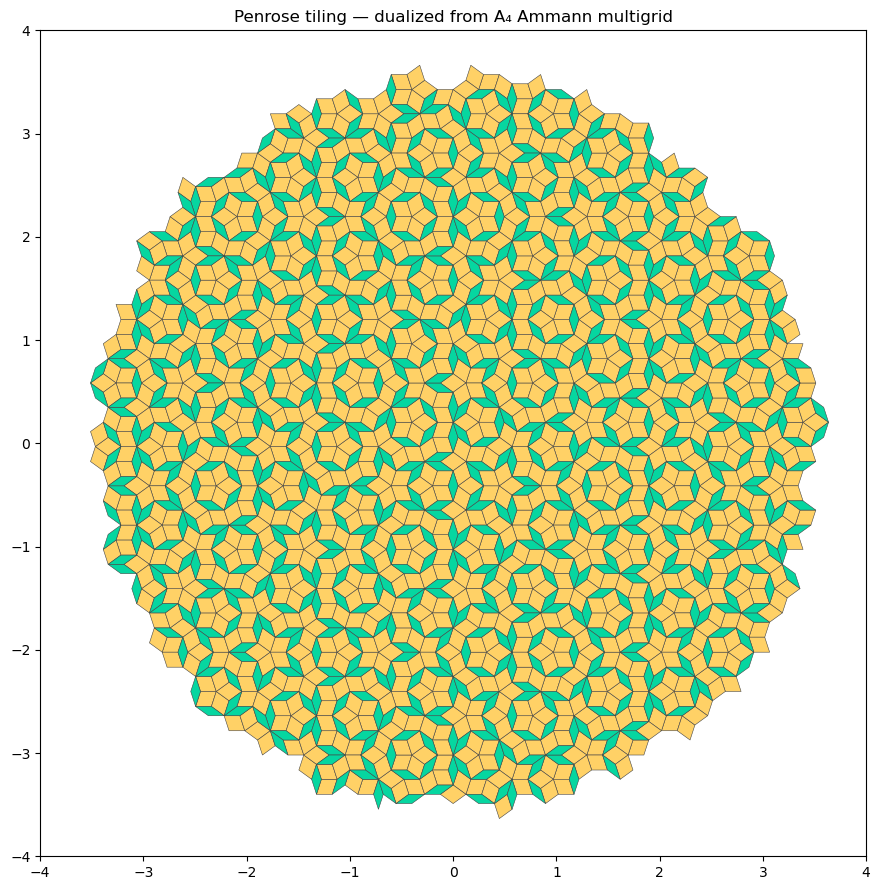

In [15]:
fig, ax = plt.subplots(figsize=(9, 9))

fat_patches  = [Polygon(t['verts']) for t in tiles if t['type'] == 'fat']
thin_patches = [Polygon(t['verts']) for t in tiles if t['type'] == 'thin']

ax.add_collection(PatchCollection(fat_patches,  facecolor='#ffd166',
                                  edgecolor='#444', linewidth=0.4))
ax.add_collection(PatchCollection(thin_patches, facecolor='#06d6a0',
                                  edgecolor='#444', linewidth=0.4))

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title('Penrose tiling — dualized from A₄ Ammann multigrid')
plt.tight_layout()
plt.show()